In [1]:
import numpy as np
import pandas as pd

In [2]:
data = {
    'study_hours': [2, 5, 8, 1, 7, 3, 6, 4, 9, 10],
    'attendance': [60, 80, 90, 40, 85, 55, 75, 65, 95, 100],
    'assignment_scores': [50, 70, 85, 30, 80, 45, 65, 60, 90, 95],
    'result': [0, 1, 1, 0, 1, 0, 1, 0, 1, 1]  # 0 = Fail, 1 = Pass
}

In [3]:
df = pd.DataFrame(data)

In [4]:
df

,study_hours,attendance,assignment_scores,result
0,2,60,50,0
1,5,80,70,1
2,8,90,85,1
3,1,40,30,0
4,7,85,80,1
5,3,55,45,0
6,6,75,65,1
7,4,65,60,0
8,9,95,90,1
9,10,100,95,1


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [16]:
X=df[['study_hours', 'attendance', 'assignment_scores']]
y=df['result']
from tensorflow.keras.layers import Dense,Dropout

In [18]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [19]:


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)



In [21]:
model = Sequential()
model.add(Dense(8, input_dim=3, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


In [23]:
history = model.fit(X_train, y_train, epochs=50, batch_size=2, verbose=1, validation_data=(X_test, y_test))


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 247ms/step - accuracy: 0.4286 - loss: 0.7215 - val_accuracy: 0.3333 - val_loss: 0.7971
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4286 - loss: 0.7061 - val_accuracy: 0.3333 - val_loss: 0.7873
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4286 - loss: 0.6916 - val_accuracy: 0.3333 - val_loss: 0.7768
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4286 - loss: 0.6777 - val_accuracy: 0.3333 - val_loss: 0.7658
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4286 - loss: 0.6640 - val_accuracy: 0.3333 - val_loss: 0.7533
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4286 - loss: 0.6503 - val_accuracy: 0.3333 - val_loss: 0.7411
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4286 - loss: 0.6359 - val_accuracy: 0.3333 - val_loss: 0.7296
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4286 - loss: 0.6222 - val_accuracy: 0.3333 - val_loss: 0.7186

In [24]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


In [25]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


Accuracy: 0.6666666666666666


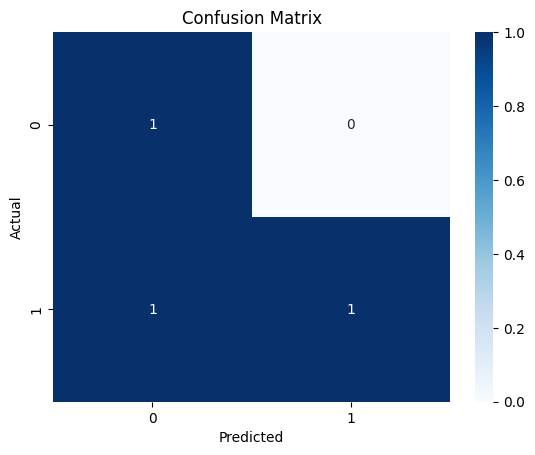

In [26]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

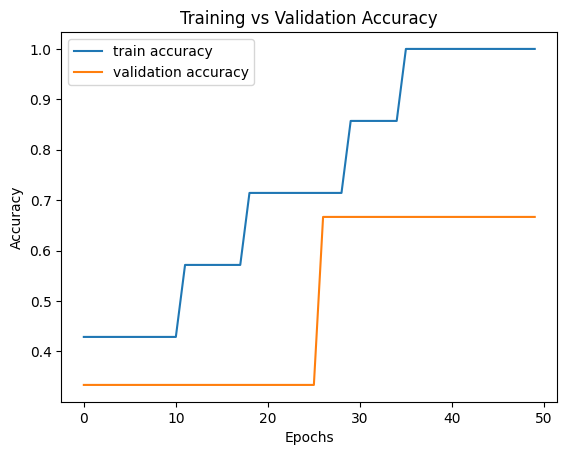

In [27]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()
